# Avaliação de Métodos de Predição de Links em Grafos

No notebook anterior, aprendemos a calcular escores estruturais para pares de vértices não conectados: Common Neighbors, Jaccard, Adamic-Adar, Resource Allocation e Preferential Attachment.

Mas calcular um escore não é o mesmo que **saber se ele funciona**. Neste notebook vamos aprender sobre uma metodologia de avaliação: como dividir o grafo, como criar exemplos positivos e negativos, como evitar vazamento de informação (*data leakage*), e quais métricas usar: ROC-AUC, Precision, Recall, F1, Precision-Recall, Average Precision, Precision@k e Recall@k.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['font.size'] = 11

print('NetworkX versão:', nx.__version__)

NetworkX versão: 3.6.1


### Motivação

Relembrando o problema de predição de links: dado um grafo

$$
G = (V, E),
$$

para cada par de vértices não conectado,

$$
(i, j) \notin E,
$$

um método produz um escore

$$
s(i, j).
$$

Surge agora uma pergunta fundamental:

> **Como podemos saber se um índice de predição de links realmente funciona?**

Olhar apenas para os pares com maior $s(i,j)$ não é suficiente, pois precisamos de uma referência (*ground truth*) para saber quais conexões deveriam, de fato, ser recuperadas ou previstas. Sem essa referência, não há como distinguir um método útil de um método que apenas parece razoável.

A solução clássica é **remover artificialmente algumas arestas conhecidas** e verificar se o método consegue recuperá-las a partir do restante do grafo. É exatamente essa ideia que vamos formalizar neste notebook.

### Ideia geral da avaliação

O procedimento conceitual pode ser resumido como:

$$
G \;\longrightarrow\; G_{\text{train}} \;\longrightarrow\; \text{predição} \;\longrightarrow\; \text{comparação com links removidos}.
$$

Em detalhes:

1. começamos com um grafo conhecido, $G$;
2. removemos uma fração das arestas, obtendo $G_{\text{train}}$;
3. usamos **apenas** $G_{\text{train}}$ para calcular os escores;
4. as arestas removidas são consideradas **exemplos positivos** ($y=1$);
5. pares que não são arestas em $G$ (o grafo original completo) são **exemplos negativos** ($y=0$);
6. verificamos se os métodos atribuem escores maiores aos exemplos positivos do que aos negativos.

Esse procedimento simula diretamente um problema de **missing link prediction**: fingimos não conhecer algumas conexões reais e verificamos se conseguimos redescobri-las.

### Grafo de exemplo

Vamos construir um grafo manual com 14 vértices, desenhado para conter:

- triângulos (necessários para os métodos baseados em vizinhança comum funcionarem);
- vértices de graus bem diferentes;
- três pequenas comunidades, conectadas por poucas arestas;
- pares estruturalmente plausíveis para conexão (dentro de cada comunidade).

In [2]:
G = nx.Graph()

arestas = [
    (0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3),   # comunidade A (densa)
    (4, 5), (4, 6), (5, 6), (6, 7), (5, 7),           # comunidade B
    (3, 4),                                            # ponte A-B
    (7, 8), (8, 9), (8, 10), (9, 10),                 # comunidade C
    (6, 8),                                            # ponte B-C
    (10, 11),                                          # vértice periférico
    (0, 12), (12, 13),                                 # cadeia periférica
]

G.add_edges_from(arestas)

print(f'Número de vértices: {G.number_of_nodes()}')
print(f'Número de arestas:  {G.number_of_edges()}')
print(f'Grau médio: {2 * G.number_of_edges() / G.number_of_nodes():.2f}')
print(f'Clustering médio: {nx.average_clustering(G):.3f}')

Número de vértices: 14
Número de arestas:  20
Grau médio: 2.86
Clustering médio: 0.488


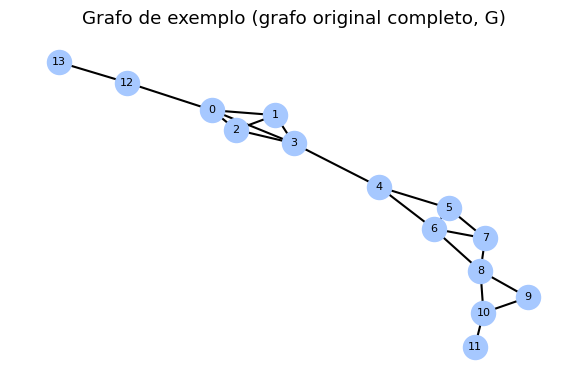

In [3]:
pos = nx.spring_layout(G, seed=SEED)

fig, ax = plt.subplots(figsize=(6, 4))
nx.draw_networkx_nodes(G, pos, node_color='#a6c8ff', node_size=300, ax=ax)
nx.draw_networkx_edges(G, pos, width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title('Grafo de exemplo (grafo original completo, G)')
ax.axis('off')
plt.tight_layout()
plt.show()

Vamos remover cinco arestas para formar nosso conjunto de teste, o suficiente para ilustrar rankings e métricas de forma não trivial, mas ainda pequeno o bastante para inspecionar manualmente. Escolhemos arestas que não são *bridges* (pontes), para não desconectar o grafo.

In [4]:
arestas_removidas_manual = [(1, 3), (2, 3), (5, 7), (8, 9), (6, 8)]

G_train = G.copy()
G_train.remove_edges_from(arestas_removidas_manual)

print(f'G original:  {G.number_of_edges()} arestas')
print(f'G_train:     {G_train.number_of_edges()} arestas (removidas: {arestas_removidas_manual})')
print(f'G_train continua conexo? {nx.is_connected(G_train)}')

G original:  20 arestas
G_train:     15 arestas (removidas: [(1, 3), (2, 3), (5, 7), (8, 9), (6, 8)])
G_train continua conexo? True


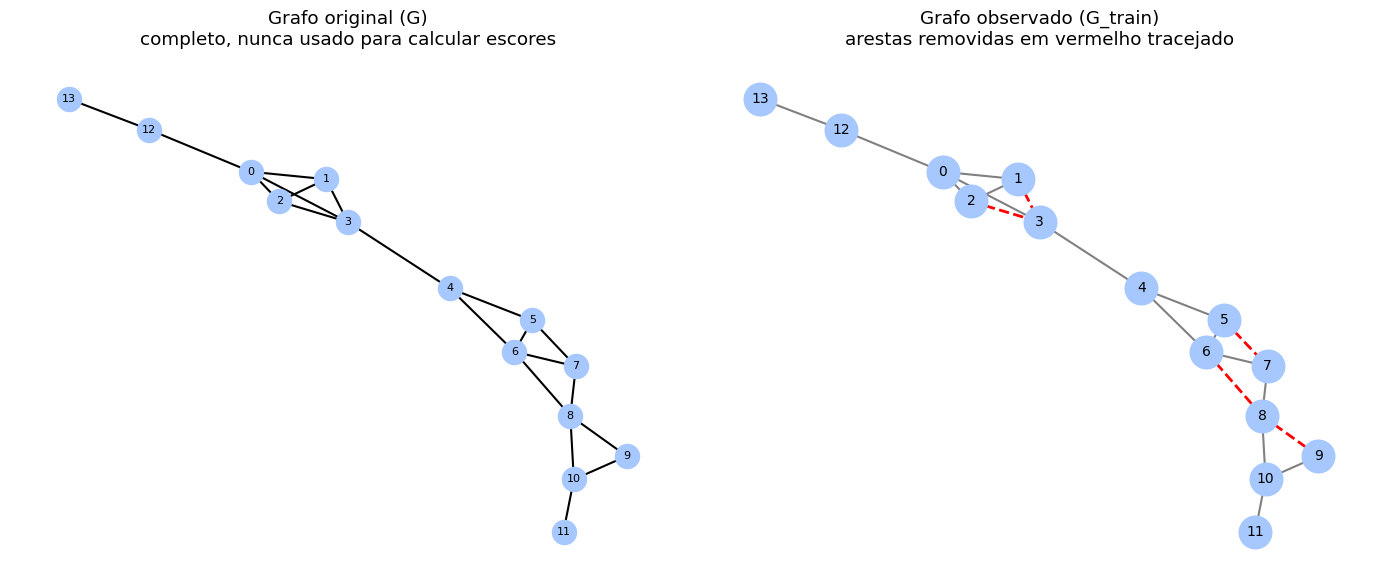

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

nx.draw_networkx_nodes(G, pos, node_color='#a6c8ff', node_size=300, ax=axes[0])
nx.draw_networkx_edges(G, pos, width=1.5, ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=8, ax=axes[0])
axes[0].set_title('Grafo original (G)\ncompleto, nunca usado para calcular escores')
axes[0].axis('off')

nx.draw_networkx_nodes(G_train, pos, node_color='#a6c8ff', node_size=550, ax=axes[1])
nx.draw_networkx_edges(G_train, pos, width=1.5, ax=axes[1], edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=arestas_removidas_manual, style='dashed',
                        edge_color='red', width=2, ax=axes[1])
nx.draw_networkx_labels(G_train, pos, font_size=10, ax=axes[1])
axes[1].set_title('Grafo observado (G_train)\narestas removidas em vermelho tracejado')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Notem que todos os escores de predição de links devem ser calculados usando **exclusivamente** `G_train`. O grafo original `G` só pode ser consultado para saber, ao final, quais pares eram realmente arestas (ou seja, para gerar o rótulo `y`), nunca para calcular os escores em si. A próxima seção mostra exatamente por quê.

### Data leakage

Esta é, possivelmente, a seção mais importante do notebook. Um erro metodológico comum, e sutil, é calcular os escores **antes** de remover as arestas de teste.

**O erro:**

```python
# ERRADO
scores = calcular_scores(G)          # calculado no grafo COMPLETO
G_train = G.copy()
G_train.remove_edges_from(arestas_teste)
```

**Por que isso é incorreto:**

As arestas de teste, se ainda presentes no momento do cálculo, já influenciam:

- **graus** dos vértices envolvidos;
- **vizinhanças** ($\Gamma(i)$ e $\Gamma(j)$ para todo vértice);
- **triângulos** e, portanto, o número de vizinhos comuns de outros pares;
- **coeficientes de clustering**;
- **caminhos** entre quaisquer dois vértices;
- e, de forma geral, **qualquer medida estrutural** calculada sobre o grafo completo.

Ou seja: mesmo que o par $(i,j)$ removido não seja diretamente consultado, sua presença no grafo pode alterar o escore de **outros** pares — inflando artificialmente o desempenho medido.

**O procedimento correto**

```python
G_train = G.copy()
G_train.remove_edges_from(arestas_teste)

# Somente agora calculamos todos os escores, usando exclusivamente G_train
scores = calcular_scores(G_train)
```

> **Toda informação utilizada para produzir uma predição deve estar disponível no momento em que a predição é feita.**

Esse é exatamente o mesmo princípio por trás do data leakage em aprendizado de máquina supervisionado tradicional: usar, durante o treinamento, informação que só estaria disponível no futuro (ou, aqui, informação que faz parte do próprio conjunto de teste) produz uma estimativa de desempenho otimista e não confiável.

### Demonstração numérica do problema

Vamos comparar o `Common Neighbors` de um par específico calculado com e sem vazamento, para tornar o efeito concreto.

In [6]:
u, v = 0, 3  # um par não conectado em G_train, mas cujo escore pode ser afetado por uma aresta removida

def common_neighbors_score(Grafo, a, b):
    return len(set(Grafo.neighbors(a)) & set(Grafo.neighbors(b)))

cn_com_vazamento = common_neighbors_score(G, u, v)          # ERRADO: usa G completo
cn_correto = common_neighbors_score(G_train, u, v)           # CORRETO: usa G_train

print(f'Common Neighbors({u},{v}) calculado em G (com vazamento):      {cn_com_vazamento}')
print(f'Common Neighbors({u},{v}) calculado em G_train (correto):      {cn_correto}')

Common Neighbors(0,3) calculado em G (com vazamento):      2
Common Neighbors(0,3) calculado em G_train (correto):      0


Mesmo esse par não sendo uma das arestas removidas, seu escore muda dependendo de qual grafo foi usado no cálculo. Isso ocorre porque o vértice `1` (vizinho de ambos) perde ou ganha uma conexão dependendo da presença da aresta `(1,3)`. Esse é o efeito do vazamento de informação: ele contamina não apenas os pares diretamente envolvidos, mas potencialmente toda a vizinhança ao redor.

### Conjunto positivo

As arestas removidas formam os **exemplos positivos** da nossa avaliação:

$$
y = 1.
$$

Estamos, na prática, perguntando:

> Entre os pares que aparecem desconectados em `G_train`, quais correspondem a arestas que sabemos que existiam no grafo original?

In [7]:
positivos = list(arestas_removidas_manual)

print(f'Número de exemplos positivos: {len(positivos)}')
print('Conjunto positivo:', positivos)

Número de exemplos positivos: 5
Conjunto positivo: [(1, 3), (2, 3), (5, 7), (8, 9), (6, 8)]


### Conjunto negativo

Os exemplos negativos são pares que não são arestas no grafo original:

$$
(i, j) \notin E.
$$

Mas há, em geral, **muitos** desses pares. Em um grafo não dirigido simples com $N$ vértices, o número total de pares possíveis é

$$
\binom{N}{2} = \frac{N(N-1)}{2},
$$

e o número de links faltantes é

$$
N_{\text{neg}} = \binom{N}{2} - |E|.
$$

Redes reais tendem a ser **esparsas**:

$$
|E| \ll \binom{N}{2},
$$

de modo que, tipicamente,

$$
N_{\text{neg}} \gg N_{\text{pos}}.
$$

Vamos calcular esses números para o nosso grafo.

In [8]:
N = G.number_of_nodes()
pares_possiveis = N * (N - 1) // 2
n_arestas = G.number_of_edges()
n_neg_total = pares_possiveis - n_arestas

print(f'N (vértices):                 {N}')
print(f'Pares possíveis C(N,2):       {pares_possiveis}')
print(f'Arestas existentes |E|:       {n_arestas}')
print(f'Não-links (N_neg):            {n_neg_total}')
print(f'Densidade |E| / C(N,2):       {n_arestas / pares_possiveis:.3f}')
print()
print(f'N_pos (arestas removidas):    {len(positivos)}')
print(f'Razão N_neg / N_pos:          {n_neg_total / len(positivos):.1f}x')

N (vértices):                 14
Pares possíveis C(N,2):       91
Arestas existentes |E|:       20
Não-links (N_neg):            71
Densidade |E| / C(N,2):       0.220

N_pos (arestas removidas):    5
Razão N_neg / N_pos:          14.2x


Mesmo neste grafo pequeno, o número de links faltantes já é muito maior que o número de positivos. Em redes reais com milhares ou milhões de vértices, essa razão costuma ser extrema. Logo, a predição de links é, fundamentalmente, um problema **fortemente desbalanceado**. Isso terá consequências diretas na escolha das métricas de avaliação.

### Negative sampling

Como frequentemente não é viável (nem necessário) usar todos os pares negativos, é comum trabalhar com uma **amostra**.

**Estratégia mais simples:**

1. obter todos os pares não conectados em `G` com `nx.non_edges(G)`;
2. excluir os links positivos removidos (eles não são negativos, apenas não estão mais visíveis em `G_train`);
3. selecionar aleatoriamente uma amostra do restante.

In [9]:
nao_arestas = list(nx.non_edges(G))
nao_arestas = [par for par in nao_arestas if par not in positivos and (par[1], par[0]) not in positivos]

print(f'Não-arestas disponíveis para amostragem: {len(nao_arestas)}')

Não-arestas disponíveis para amostragem: 71


In [10]:
rng = np.random.default_rng(SEED)

indices_balanceado = rng.choice(
    len(nao_arestas),
    size=len(positivos),
    replace=False
)

negativos_balanceado = [nao_arestas[i] for i in indices_balanceado]

print(f'Número de exemplos negativos (1:1): {len(negativos_balanceado)}')
print('Conjunto negativo balanceado:', negativos_balanceado)

Número de exemplos negativos (1:1): 5
Conjunto negativo balanceado: [(6, 10), (3, 6), (5, 8), (0, 9), (11, 13)]


#### O caso balanceado

Aqui escolhemos

$$
N_{\text{neg}} = N_{\text{pos}},
$$

ou seja, uma amostra balanceada 1:1. Isso facilita bastante a análise. Histogramas, curvas ROC e Precision-Recall ficam mais fáceis de interpretar, mas é importante ter em mente que **essa proporção não representa a distribuição real da rede**, onde os negativos são, de longe, a maioria.

### Três estratégias possíveis:

- **1:1** entre positivos e negativos (a mais simples de interpretar);
- **proportção de negativos por positivo** (ex.: 1:5, 1:10), mais próximo da proporção real, mas ainda controlado;
- **todos os pares negativos**, o cenário mais realista, porém computacionalmente mais caro e com desbalanceamento extremo.

Para tornar a demonstração das próximas seções (ranking, Precision@k com $k$ maior, curvas ROC e Precision-Recall) mais informativa, vamos usar a partir daqui a **terceira estratégia: todos os pares negativos disponíveis**, como conjunto principal de trabalho. Isso também tem a vantagem de ser o cenário mais realista: veremos como esse forte desbalanceamento (poucos positivos, muitos negativos) afeta a interpretação das métricas.

In [11]:
negativos = nao_arestas  # todos os pares negativos disponíveis

print(f'Número de exemplos negativos (todos): {len(negativos)}')
print(f'Número de exemplos positivos:         {len(positivos)}')
print(f'Razão negativos:positivos:            {len(negativos) / len(positivos):.1f}:1')

Número de exemplos negativos (todos): 71
Número de exemplos positivos:         5
Razão negativos:positivos:            14.2:1


### Construção da tabela de avaliação

Vamos reunir positivos e negativos em um único DataFrame, com uma linha por par de vértices, contendo o rótulo verdadeiro

$$
y =
\begin{cases}
1, & \text{link removido (positivo)} \\
0, & \text{não-link (negativo)}
\end{cases}
$$

e os cinco escores estruturais, todos calculados a partir de `G_train`.

In [12]:
pares_avaliacao = positivos + negativos
rotulos = [1] * len(positivos) + [0] * len(negativos)

df_avaliacao = pd.DataFrame(pares_avaliacao, columns=['u', 'v'])
df_avaliacao['y'] = rotulos

df_avaliacao

,u,v,y
0,1,3,1
1,2,3,1
2,5,7,1
3,8,9,1
4,6,8,1
...,...,...,...
71,9,13,0
72,10,12,0
73,10,13,0
74,11,12,0


In [13]:
df_avaliacao['common_neighbors'] = [
    common_neighbors_score(G_train, u, v) for u, v in pares_avaliacao
]

jac = {(u, v): s for u, v, s in nx.jaccard_coefficient(G_train, pares_avaliacao)}
aa = {(u, v): s for u, v, s in nx.adamic_adar_index(G_train, pares_avaliacao)}
ra = {(u, v): s for u, v, s in nx.resource_allocation_index(G_train, pares_avaliacao)}
pa = {(u, v): s for u, v, s in nx.preferential_attachment(G_train, pares_avaliacao)}

df_avaliacao['jaccard'] = df_avaliacao.apply(lambda r: jac[(r['u'], r['v'])], axis=1)
df_avaliacao['adamic_adar'] = df_avaliacao.apply(lambda r: aa[(r['u'], r['v'])], axis=1)
df_avaliacao['resource_allocation'] = df_avaliacao.apply(lambda r: ra[(r['u'], r['v'])], axis=1)
df_avaliacao['preferential_attachment'] = df_avaliacao.apply(lambda r: pa[(r['u'], r['v'])], axis=1)

df_avaliacao

,u,v,y,common_neighbors,jaccard,adamic_adar,resource_allocation,preferential_attachment
0,1,3,1,1,0.333333,0.721348,0.250000,4
1,2,3,1,1,0.333333,0.721348,0.250000,4
2,5,7,1,1,0.333333,0.910239,0.333333,4
3,8,9,1,1,0.500000,0.910239,0.333333,2
4,6,8,1,1,0.250000,1.442695,0.500000,6
...,...,...,...,...,...,...,...,...
71,9,13,0,0,0.000000,0.000000,0.000000,1
72,10,12,0,0,0.000000,0.000000,0.000000,6
73,10,13,0,0,0.000000,0.000000,0.000000,3
74,11,12,0,0,0.000000,0.000000,0.000000,2


Cada uma dessas cinco colunas: `common_neighbors`, `jaccard`, `adamic_adar`, `resource_allocation`, `preferential_attachment`, funciona agora como um **escore de classificação** para a coluna `y`.

**Importante:** não vamos transformar esses escores em probabilidades. Eles não são calibrados nem normalizados de forma alguma, apenas precisam **ordenar** corretamente positivos acima de negativos. Essa é a ideia central por trás de praticamente todas as métricas deste notebook.

### Common Neighbors

Vamos começar a avaliação usando apenas o `Common Neighbors`, o mais simples dos cinco índices. A primeira pergunta é bem direta:

> **Os links positivos tendem a receber valores maiores do que os negativos?**

Uma forma simples e visual de responder é comparar as distribuições do escore para os dois grupos ($y=1$ e $y=0$).

In [14]:
positivos_scores = df_avaliacao.loc[df_avaliacao['y'] == 1, 'common_neighbors']
negativos_scores = df_avaliacao.loc[df_avaliacao['y'] == 0, 'common_neighbors']

print('Estatísticas — positivos:')
print(positivos_scores.describe())
print()
print('Estatísticas — negativos:')
print(negativos_scores.describe())

Estatísticas — positivos:
count    5.0
mean     1.0
std      0.0
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0
Name: common_neighbors, dtype: float64

Estatísticas — negativos:
count    71.000000
mean      0.154930
std       0.364413
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000
Name: common_neighbors, dtype: float64


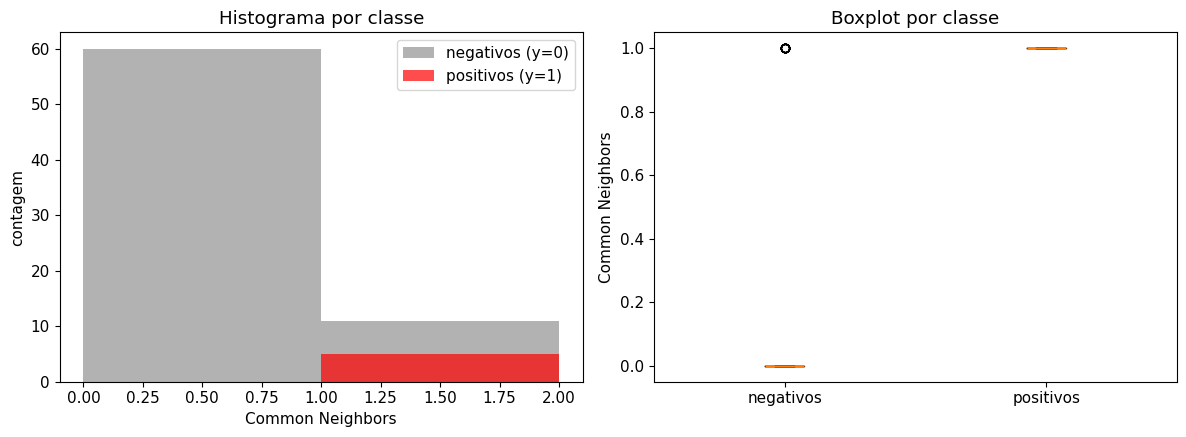

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bins = range(0, int(df_avaliacao['common_neighbors'].max()) + 2)
axes[0].hist(negativos_scores, bins=bins, alpha=0.6, label='negativos (y=0)', color='gray')
axes[0].hist(positivos_scores, bins=bins, alpha=0.7, label='positivos (y=1)', color='red')
axes[0].set_xlabel('Common Neighbors')
axes[0].set_ylabel('contagem')
axes[0].set_title('Histograma por classe')
axes[0].legend()

axes[1].boxplot([negativos_scores, positivos_scores], tick_labels=['negativos', 'positivos'])
axes[1].set_ylabel('Common Neighbors')
axes[1].set_title('Boxplot por classe')

plt.tight_layout()
plt.show()

Já é possível notar visualmente se os positivos tendem a se concentrar em valores mais altos do que os negativos. Essa comparação de distribuições é, na prática, uma primeira forma (informal, mas útil) de avaliar o desempenho de um escore de classificação, e é exatamente a base intuitiva sobre a qual a ROC-AUC será construída na Seção 13.

Uma forma mais direta de avaliar é simplesmente **ordenar** todos os pares pelo escore, do maior para o menor, e observar onde os positivos aparecem.

In [16]:
resultado = df_avaliacao.sort_values('common_neighbors', ascending=False).reset_index(drop=True)

resultado[['u', 'v', 'y', 'common_neighbors']].head(15)

,u,v,y,common_neighbors
0,1,3,1,1
1,2,3,1,1
2,5,7,1,1
3,8,9,1,1
4,6,8,1,1
5,0,4,0,1
6,2,12,0,1
7,4,7,0,1
8,3,12,0,1
9,3,6,0,1


In [17]:
posicoes_positivos = resultado.index[resultado['y'] == 1].tolist()
posicoes_positivos = [p + 1 for p in posicoes_positivos]  # posição começando em 1

print(f'Total de pares avaliados: {len(resultado)}')
print(f'Posições ocupadas pelos {len(positivos)} links positivos no ranking:')
for (u, v), posicao in zip(positivos, posicoes_positivos):
    print(f'  par ({u}, {v}): posição {posicao} de {len(resultado)}')

Total de pares avaliados: 76
Posições ocupadas pelos 5 links positivos no ranking:
  par (1, 3): posição 1 de 76
  par (2, 3): posição 2 de 76
  par (5, 7): posição 3 de 76
  par (8, 9): posição 4 de 76
  par (6, 8): posição 5 de 76


- **Quantos positivos aparecem nas primeiras posições?** Isso pode ser lido diretamente da tabela acima.
- **Em que posição aparece cada link removido?** Mostrado explicitamente célula acima, alguns pares (com mais vizinhos comuns) tendem a aparecer bem no topo; outros, mais distantes estruturalmente, podem ficar no meio ou no final do ranking.
- **Por que ranking é uma maneira natural de avaliar link prediction?** Porque, na prática, ninguém usa um sistema de recomendação para classificar *todos* os pares possíveis como "sim" ou "não", o que importa é a **ordem** em que os candidatos são apresentados. Essa observação motiva diretamente as próximas métricas: Precision@k e Recall@k.

### Precision@k

Uma das métricas mais naturais para esse problema é **Precision@k**:

$$
Precision@k = \frac{\text{número de links positivos entre os primeiros } k}{k}.
$$

**Interpretação:**

> Se pudéssemos recomendar apenas 10 novos links, quantos deles seriam realmente corretos?

Essa é exatamente a pergunta que importa em sistemas de recomendação: um usuário não vai olhar milhares de sugestões, apenas as primeiras.

In [18]:
def precision_at_k(y_true, scores, k):
    '''Calcula Precision@k: proporcao de positivos entre os k pares com maior score.'''
    ordem = np.argsort(scores)[::-1]  # índices do maior para o menor score
    top_k = ordem[:k]
    y_top_k = np.array(y_true)[top_k]
    return y_top_k.sum() / k

y_true = df_avaliacao['y'].values
scores_cn = df_avaliacao['common_neighbors'].values

for k in [5, 10, 20, 50]:
    p_at_k = precision_at_k(y_true, scores_cn, k)
    print(f'Precision@{k:<3d} = {p_at_k:.3f}')

Precision@5   = 0.200
Precision@10  = 0.100
Precision@20  = 0.250
Precision@50  = 0.100


### Recall@k

De forma complementar, **Recall@k** mede quantos dos positivos totais conseguimos "capturar" olhando apenas para os $k$ primeiros:

$$
Recall@k = \frac{\text{positivos encontrados entre os primeiros } k}{\text{número total de positivos}}.
$$

In [19]:
def recall_at_k(y_true, scores, k):
    '''Calcula Recall@k: proporcao dos positivos totais capturados nos k primeiros.'''
    ordem = np.argsort(scores)[::-1]
    top_k = ordem[:k]
    y_top_k = np.array(y_true)[top_k]
    total_positivos = np.array(y_true).sum()
    return y_top_k.sum() / total_positivos

for k in [5, 10, 20, 50]:
    r_at_k = recall_at_k(y_true, scores_cn, k)
    print(f'Recall@{k:<3d} = {r_at_k:.3f}')

Recall@5   = 0.200
Recall@10  = 0.200
Recall@20  = 1.000
Recall@50  = 1.000


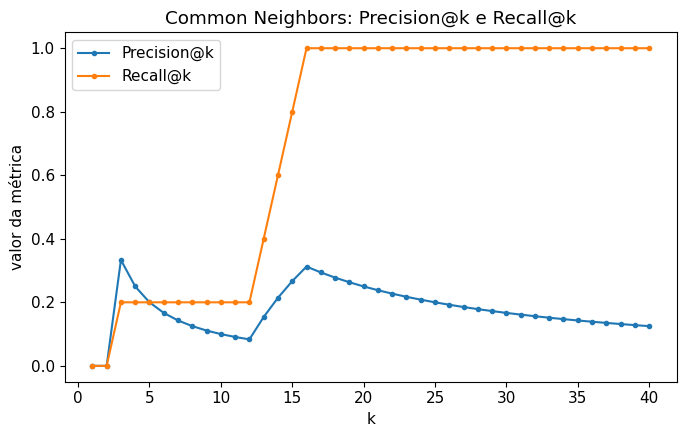

In [20]:
ks = list(range(1, 41))
precisions = [precision_at_k(y_true, scores_cn, k) for k in ks]
recalls = [recall_at_k(y_true, scores_cn, k) for k in ks]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, precisions, marker='.', label='Precision@k')
ax.plot(ks, recalls, marker='.', label='Recall@k')
ax.set_xlabel('k')
ax.set_ylabel('valor da métrica')
ax.set_title('Common Neighbors: Precision@k e Recall@k')
ax.legend()
plt.tight_layout()
plt.show()

O gráfico deixa claro o compromisso entre as duas métricas: aumentar $k$ **tende a aumentar o Recall** (capturamos mais positivos ao olhar mais candidatos), mas **pode reduzir a Precision** (olhamos também mais negativos, diluindo a proporção de acertos). Esse é o mesmo compromisso fundamental que reencontraremos na curva Precision-Recall, que apresentamos a seguir.

### ROC-AUC

A curva **ROC** (*Receiver Operating Characteristic*) resume o comportamento de um classificador quando variamos um limiar de decisão. Para cada limiar $\tau$, um par é classificado como positivo se $s(i,j) > \tau$.

Duas taxas são calculadas para cada limiar:

$$
TPR = \frac{TP}{TP + FN} \qquad \text{(taxa de verdadeiros positivos, = Recall)}
$$

$$
FPR = \frac{FP}{FP + TN} \qquad \text{(taxa de falsos positivos)}
$$

A curva ROC plota $TPR$ contra $FPR$ para todos os limiares possíveis.

In [21]:
fpr, tpr, thresholds = roc_curve(y_true, scores_cn)
auc = roc_auc_score(y_true, scores_cn)

print(f'ROC-AUC (Common Neighbors) = {auc:.3f}')

ROC-AUC (Common Neighbors) = 0.923


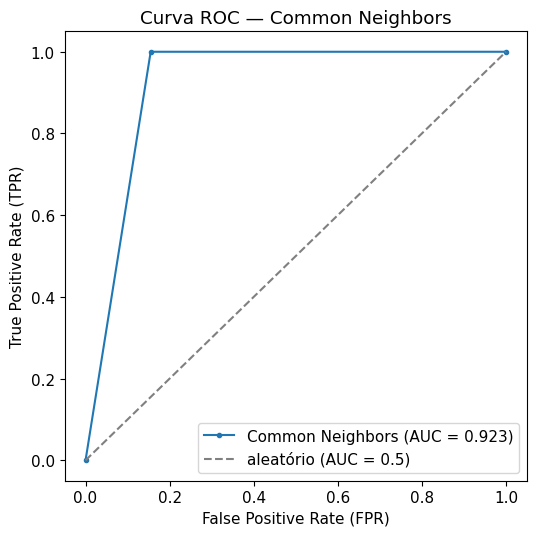

In [22]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr, tpr, marker='.', label=f'Common Neighbors (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='aleatório (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('Curva ROC — Common Neighbors')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação intuitiva da AUC**

$$
AUC \approx P(s_{+} > s_{-}),
$$

ou seja:

> **ROC-AUC mede aproximadamente a probabilidade de um exemplo positivo escolhido aleatoriamente receber um escore maior do que um exemplo negativo escolhido aleatoriamente.**

Valores de referência:

- $AUC \approx 0.5$: desempenho aproximadamente aleatório (a curva fica próxima da diagonal);
- $AUC = 1.0$: separação perfeita entre positivos e negativos;
- $AUC < 0.5$: a ordenação é sistematicamente **pior** que aleatória (o que normalmente indica algum erro, como inverter o sinal do escore).

### Limitação da ROC-AUC em redes esparsas

A predição de links costuma ser um problema **altamente desbalanceado**, o número de negativos costuma superar em muito o número de positivos.

Isso é relevante porque a $FPR$ tem os negativos no denominador ($FP + TN$), que é um número muito grande. Como resultado, a ROC-AUC pode apresentar valores aparentemente bons mesmo quando o desempenho entre os pares **mais bem classificados**, os que realmente importariam em uma aplicação prática, como Precision@10, não é tão útil.

Em outras palavras: a ROC-AUC resume o comportamento do classificador em **toda a faixa de limiares**, incluindo regiões pouco relevantes na prática (quando quase todo par é classificado como positivo). Isso motiva o uso complementar de métricas focadas na classe minoritária — é aí que entra a análise de **Precision e Recall**.

### Precision e Recall

Revisando as definições:

$$
Precision = \frac{TP}{TP + FP} \qquad Recall = \frac{TP}{TP + FN}.
$$

Diferente da curva ROC (que varia o limiar continuamente), para obter um único valor de Precision e Recall precisamos **escolher um limiar** específico:

$$
s(i, j) > \tau.
$$

In [23]:
limiar = 1  # um exemplo de limiar arbitrário para Common Neighbors

y_pred = (scores_cn > limiar).astype(int)

precision_exemplo = precision_score(y_true, y_pred, zero_division=0)
recall_exemplo = recall_score(y_true, y_pred, zero_division=0)
f1_exemplo = f1_score(y_true, y_pred, zero_division=0)

print(f'Limiar escolhido: {limiar}')
print(f'Precision = {precision_exemplo:.3f}')
print(f'Recall    = {recall_exemplo:.3f}')
print(f'F1-score  = {f1_exemplo:.3f}')

Limiar escolhido: 1
Precision = 0.000
Recall    = 0.000
F1-score  = 0.000


**Por que escolher um limiar é problemático:**

Índices como Common Neighbors ou Adamic-Adar não têm uma escala natural ou interpretável como "probabilidade", um `Common Neighbors = 2` não significa nada em termos absolutos, apenas relativos (2 é maior que 1, menor que 3). Isso torna a escolha de $\tau$ bastante **arbitrária**: um limiar diferente pode mudar drasticamente Precision e Recall, sem que o método em si tenha mudado.

Essa limitação motiva diretamente a próxima seção: em vez de fixar um limiar, podemos observar Precision e Recall **para todos os limiares possíveis** simultaneamente.

### Curva Precision-Recall

A curva Precision-Recall mostra exatamente essa relação, variando o limiar de forma contínua, de maneira análoga à curva ROC.

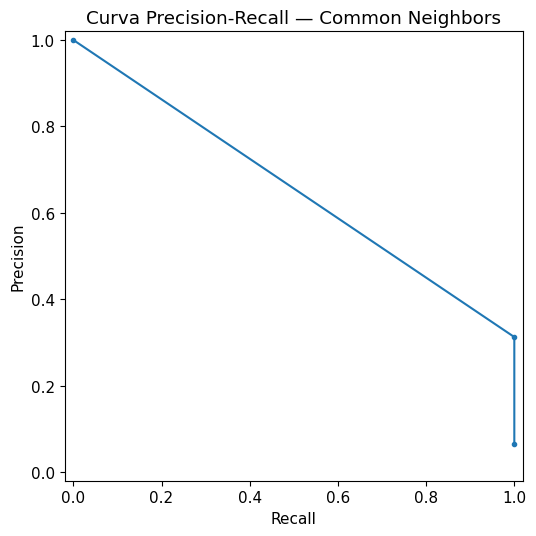

In [24]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, scores_cn)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(recall_curve, precision_curve, marker='.')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — Common Neighbors')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

A curva mostra diretamente o compromisso entre:

- **encontrar muitos links positivos** (Recall alto);
- **manter uma alta proporção de previsões corretas** (Precision alto).

Um único número que resume essa curva é a **Average Precision (AP)**:

In [25]:
ap_cn = average_precision_score(y_true, scores_cn)
print(f'Average Precision (Common Neighbors) = {ap_cn:.3f}')

Average Precision (Common Neighbors) = 0.312


A Average Precision **não** é uma simples média aritmética das precisões calculadas em vários limiares. Formalmente, ela é calculada como

$$
AP = \sum_n (R_n - R_{n-1}) \, P_n,
$$

ou seja, uma soma ponderada das precisões em cada limiar, com pesos dados pelo **aumento no Recall** entre limiares consecutivos, o que corresponde à área sob a curva Precision-Recall (sob a convenção de interpolação usada pelo scikit-learn). Essa distinção é sutil, mas importante: uma média aritmética simples ignoraria como o Recall evolui ao longo dos limiares.

### Comparação entre ROC e Precision-Recall

Vamos colocar as duas curvas lado a lado para o mesmo método.

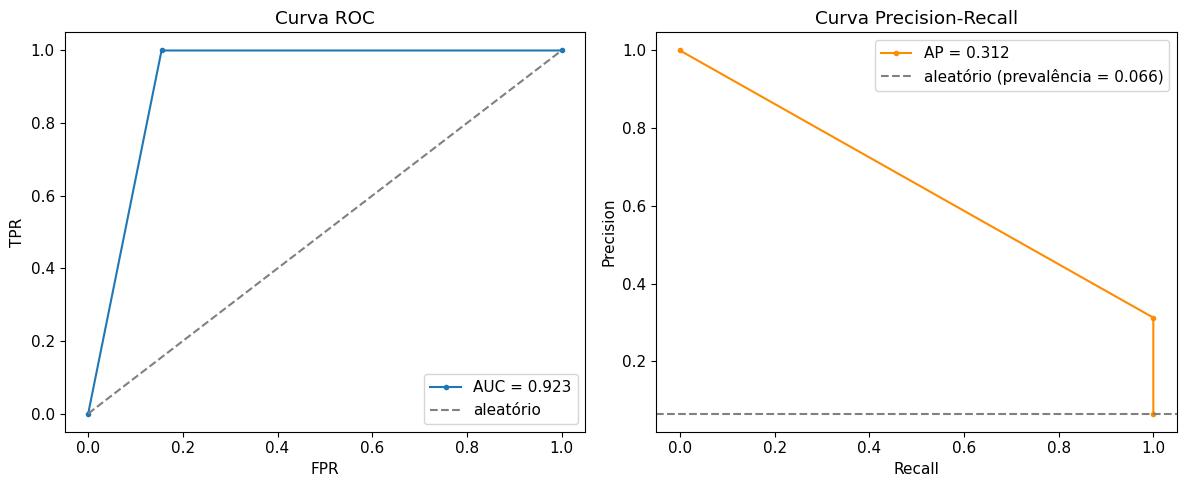

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, marker='.', label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='aleatório')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC')
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, marker='.', color='darkorange', label=f'AP = {ap_cn:.3f}')
prevalencia = y_true.sum() / len(y_true)
axes[1].axhline(prevalencia, linestyle='--', color='gray', label=f'aleatório (prevalência = {prevalencia:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

- A **curva ROC** é útil quando estamos interessados no comportamento geral do classificador, e é relativamente **insensível ao desbalanceamento de classes** (a linha de base "aleatória" é sempre a diagonal, independentemente da prevalência de positivos).
- A **curva Precision-Recall** é mais informativa quando a classe positiva é rara, que é exatamente o caso da predição de links, porque sua linha de base "aleatória" (a prevalência de positivos) reflete diretamente o desbalanceamento.

Como vimos anteriormente, a ROC-AUC pode permanecer alta mesmo quando a Precision nos primeiros $k$ resultados é baixa, justamente porque a FPR "dilui" o efeito dos negativos (que são muitos). A curva Precision-Recall e a Average Precision tendem a expor esse problema de forma mais direta.

### Avaliação dos cinco métodos

Vamos agora repetir todo o processo de avaliação para os cinco índices estruturais, usando a mesma tabela `df_avaliacao` (mesmos positivos e negativos, garantindo uma comparação justa).

Para cada método, calculamos:

- ROC-AUC;
- Average Precision;
- Precision@5, Precision@10, Precision@20;
- Recall@10, Recall@20.

In [27]:
metodos = ['common_neighbors', 'jaccard', 'adamic_adar', 'resource_allocation', 'preferential_attachment']

linhas_resumo = []
for metodo in metodos:
    s = df_avaliacao[metodo].values
    linha = {
        'metodo': metodo,
        'roc_auc': roc_auc_score(y_true, s),
        'average_precision': average_precision_score(y_true, s),
        'P@5': precision_at_k(y_true, s, 5),
        'P@10': precision_at_k(y_true, s, 10),
        'P@20': precision_at_k(y_true, s, 20),
        'R@10': recall_at_k(y_true, s, 10),
        'R@20': recall_at_k(y_true, s, 20),
    }
    linhas_resumo.append(linha)

df_resumo = pd.DataFrame(linhas_resumo).set_index('metodo')
df_resumo = df_resumo.round(3)
df_resumo.sort_values('roc_auc', ascending=False)

,roc_auc,average_precision,P@5,P@10,P@20,R@10,R@20
metodo,,,,,,,
jaccard,0.939,0.373,0.4,0.4,0.25,0.8,1.0
common_neighbors,0.923,0.312,0.2,0.1,0.25,0.2,1.0
adamic_adar,0.911,0.284,0.2,0.2,0.25,0.4,1.0
resource_allocation,0.911,0.284,0.2,0.2,0.25,0.4,1.0
preferential_attachment,0.517,0.074,0.0,0.0,0.05,0.0,0.2


In [28]:
print('Ordenado por ROC-AUC:')
print(df_resumo.sort_values('roc_auc', ascending=False).index.tolist())
print()
print('Ordenado por P@10:')
print(df_resumo.sort_values('P@10', ascending=False).index.tolist())
print()
print('Ordenado por Average Precision:')
print(df_resumo.sort_values('average_precision', ascending=False).index.tolist())

Ordenado por ROC-AUC:
['jaccard', 'common_neighbors', 'adamic_adar', 'resource_allocation', 'preferential_attachment']

Ordenado por P@10:
['jaccard', 'resource_allocation', 'adamic_adar', 'common_neighbors', 'preferential_attachment']

Ordenado por Average Precision:
['jaccard', 'common_neighbors', 'adamic_adar', 'resource_allocation', 'preferential_attachment']


Se as ordenações forem diferentes, isso reforça um ponto central deste notebook: **não existe uma única métrica "correta"**, cada uma responde a uma pergunta ligeiramente diferente, e a escolha depende da aplicação.

### Curvas ROC de vários métodos

Vamos visualizar as cinco curvas ROC em um único gráfico, com a ROC-AUC de cada método no rótulo.

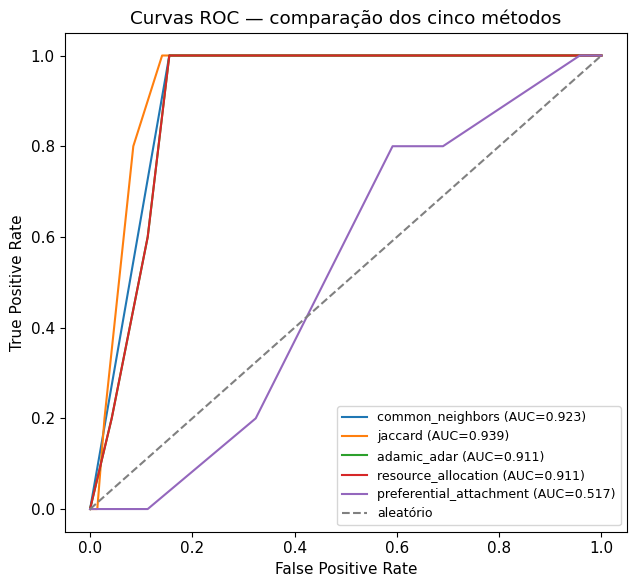

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 6))

for metodo in metodos:
    s = df_avaliacao[metodo].values
    fpr_m, tpr_m, _ = roc_curve(y_true, s)
    auc_m = roc_auc_score(y_true, s)
    ax.plot(fpr_m, tpr_m, label=f'{metodo} (AUC={auc_m:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='aleatório')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — comparação dos cinco métodos')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Curvas Precision-Recall de vários métodos

Repetimos o mesmo gráfico para Precision-Recall, com a Average Precision no rótulo.

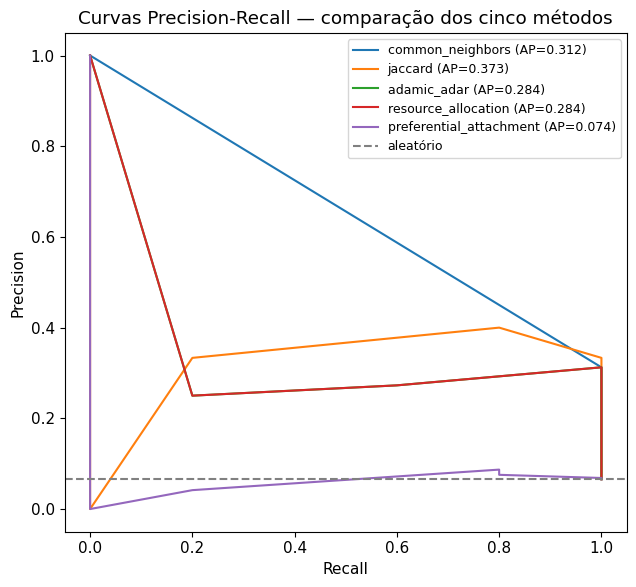

In [30]:
fig, ax = plt.subplots(figsize=(6.5, 6))

for metodo in metodos:
    s = df_avaliacao[metodo].values
    prec_m, rec_m, _ = precision_recall_curve(y_true, s)
    ap_m = average_precision_score(y_true, s)
    ax.plot(rec_m, prec_m, label=f'{metodo} (AP={ap_m:.3f})')

ax.axhline(prevalencia, linestyle='--', color='gray', label='aleatório')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall — comparação dos cinco métodos')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Efeito do número de negativos

Vamos agora investigar diretamente como a escolha do número de negativos afeta a avaliação, comparando:

$$
N_{\text{neg}} = N_{\text{pos}} \quad (\text{1:1}) \qquad\text{vs.}\qquad N_{\text{neg}} = 5\,N_{\text{pos}} \quad (\text{1:5}) \qquad\text{vs.}\qquad N_{\text{neg}} = 10\,N_{\text{pos}} \quad (\text{1:10}).
$$

In [31]:
def amostrar_negativos(pool, n, rng):
    indices = rng.choice(len(pool), size=min(n, len(pool)), replace=False)
    return [pool[i] for i in indices]

rng2 = np.random.default_rng(SEED)

configuracoes = {'1:1': 1, '1:5': 5, '1:10': 10}
resultados_desbalanceamento = []

for nome_config, multiplicador in configuracoes.items():
    n_neg = multiplicador * len(positivos)
    neg_amostra = amostrar_negativos(nao_arestas, n_neg, rng2)

    pares_config = positivos + neg_amostra
    y_config = np.array([1] * len(positivos) + [0] * len(neg_amostra))

    cn_config = np.array([common_neighbors_score(G_train, u, v) for u, v in pares_config])

    resultados_desbalanceamento.append({
        'configuracao': nome_config,
        'N_pos': len(positivos),
        'N_neg': len(neg_amostra),
        'roc_auc': roc_auc_score(y_config, cn_config),
        'average_precision': average_precision_score(y_config, cn_config),
        'P@10': precision_at_k(y_config, cn_config, min(10, len(y_config))),
    })

df_desbalanceamento = pd.DataFrame(resultados_desbalanceamento).round(3)
df_desbalanceamento

,configuracao,N_pos,N_neg,roc_auc,average_precision,P@10
0,1:1,5,5,0.90,0.833,0.5
1,1:5,5,25,0.90,0.500,0.5
2,1:10,5,50,0.93,0.417,0.3


Observe como a **ROC-AUC** tende a se manter relativamente estável entre as três configurações, enquanto **Average Precision** (e, em menor grau, Precision@k) tende a **diminuir** conforme aumentamos a proporção de negativos, mesmo usando exatamente o mesmo método (Common Neighbors) e os mesmos positivos.

Isso confirma, de forma empírica, a discussão anterior: a ROC-AUC é relativamente **insensível à proporção de classes**, enquanto Precision e Average Precision **dependem fortemente da prevalência dos positivos**. Ao comparar métodos, ou ao comparar o mesmo método em experimentos diferentes, é essencial relatar também a proporção de negativos usada, ou os resultados podem não ser comparáveis.

### Randomização repetida

Até agora, avaliamos os métodos usando uma **única** escolha de arestas removidas. Mas essa escolha foi, em si, arbitrária, outra escolha de arestas (ou de negativos) poderia produzir resultados um pouco diferentes.

Vamos repetir todo o experimento várias vezes, cada vez com uma seleção aleatória diferente de arestas de teste, e observar a variabilidade dos resultados.

In [32]:
def avaliar_uma_repeticao(G_completo, frac_teste, rng):
    arestas = list(G_completo.edges())
    n_teste = max(1, int(len(arestas) * frac_teste))

    indices_teste = rng.choice(len(arestas), size=n_teste, replace=False)
    arestas_teste = [arestas[i] for i in indices_teste]

    G_tr = G_completo.copy()
    G_tr.remove_edges_from(arestas_teste)

    if not nx.is_connected(G_tr):
        return None  # descarta repetições que desconectam a rede

    pool_neg = [p for p in nx.non_edges(G_completo)
                if p not in arestas_teste and (p[1], p[0]) not in arestas_teste]
    neg_amostra = amostrar_negativos(pool_neg, len(arestas_teste), rng)

    pares = arestas_teste + neg_amostra
    y = np.array([1] * len(arestas_teste) + [0] * len(neg_amostra))

    resultado_rep = {}
    for metodo, funcao_nx in [
        ('common_neighbors', None),
        ('jaccard', nx.jaccard_coefficient),
        ('adamic_adar', nx.adamic_adar_index),
        ('resource_allocation', nx.resource_allocation_index),
        ('preferential_attachment', nx.preferential_attachment),
    ]:
        if metodo == 'common_neighbors':
            s = np.array([common_neighbors_score(G_tr, u, v) for u, v in pares])
        else:
            mapa = {(u, v): sc for u, v, sc in funcao_nx(G_tr, pares)}
            s = np.array([mapa[(u, v)] for u, v in pares])

        resultado_rep[f'{metodo}__roc_auc'] = roc_auc_score(y, s)
        resultado_rep[f'{metodo}__ap'] = average_precision_score(y, s)

    return resultado_rep

In [33]:
n_repeticoes = 30
rng3 = np.random.default_rng(SEED)

resultados_repeticoes = []
for _ in range(n_repeticoes):
    r = avaliar_uma_repeticao(G, frac_teste=0.2, rng=rng3)
    if r is not None:
        resultados_repeticoes.append(r)

df_repeticoes = pd.DataFrame(resultados_repeticoes)
print(f'Número de repetições válidas: {len(df_repeticoes)} de {n_repeticoes}')
df_repeticoes.head()

Número de repetições válidas: 6 de 30


,common_neighbors__roc_auc,common_neighbors__ap,jaccard__roc_auc,jaccard__ap,adamic_adar__roc_auc,adamic_adar__ap,resource_allocation__roc_auc,resource_allocation__ap,preferential_attachment__roc_auc,preferential_attachment__ap
0,0.87500,0.875000,0.87500,0.875000,0.87500,0.875000,0.87500,0.875000,0.25000,0.450000
1,0.78125,0.750000,0.71875,0.645833,0.78125,0.750000,0.78125,0.750000,0.62500,0.566667
2,1.00000,1.000000,1.00000,1.000000,1.00000,1.000000,1.00000,1.000000,0.62500,0.583333
3,0.65625,0.666667,0.68750,0.750000,0.62500,0.666667,0.62500,0.666667,0.50000,0.500000
4,0.90625,0.850000,0.96875,0.950000,0.93750,0.900000,0.93750,0.900000,0.34375,0.475000


In [34]:
resumo_repeticoes = []
for metodo in metodos:
    col_auc = df_repeticoes[f'{metodo}__roc_auc']
    col_ap = df_repeticoes[f'{metodo}__ap']
    resumo_repeticoes.append({
        'metodo': metodo,
        'roc_auc_media': col_auc.mean(),
        'roc_auc_desvio': col_auc.std(),
        'roc_auc_min': col_auc.min(),
        'roc_auc_max': col_auc.max(),
        'ap_media': col_ap.mean(),
        'ap_desvio': col_ap.std(),
    })

df_resumo_repeticoes = pd.DataFrame(resumo_repeticoes).set_index('metodo').round(3)
df_resumo_repeticoes

,roc_auc_media,roc_auc_desvio,roc_auc_min,roc_auc_max,ap_media,ap_desvio
metodo,,,,,,
common_neighbors,0.849,0.118,0.656,1.000,0.824,0.114
jaccard,0.854,0.128,0.688,1.000,0.841,0.130
adamic_adar,0.859,0.137,0.625,1.000,0.849,0.120
resource_allocation,0.859,0.137,0.625,1.000,0.849,0.120
preferential_attachment,0.464,0.151,0.250,0.625,0.512,0.052


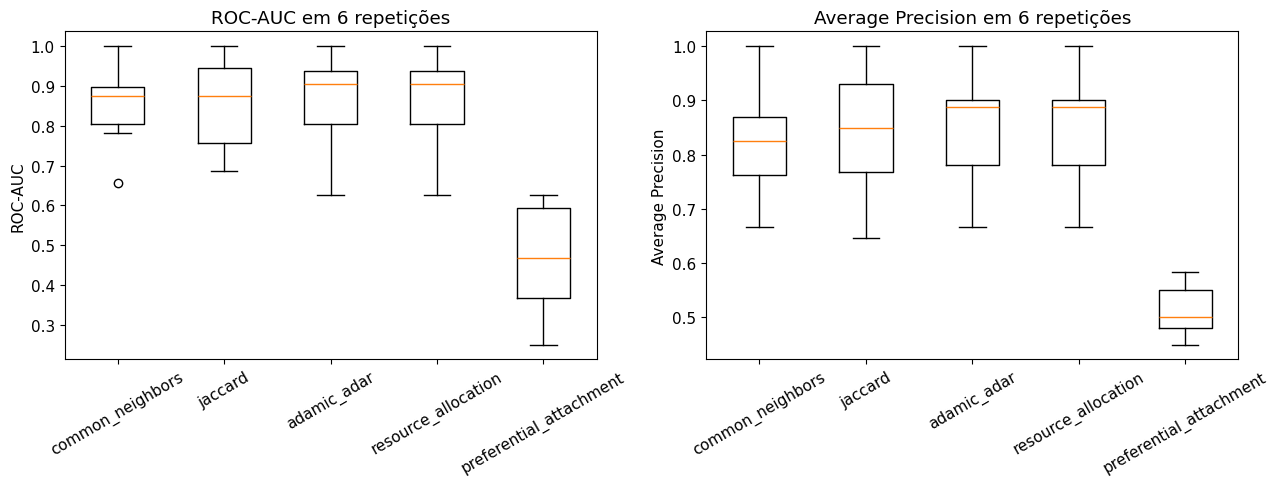

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dados_auc = [df_repeticoes[f'{m}__roc_auc'] for m in metodos]
axes[0].boxplot(dados_auc, tick_labels=metodos)
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title(f'ROC-AUC em {len(df_repeticoes)} repetições')
axes[0].tick_params(axis='x', rotation=30)

dados_ap = [df_repeticoes[f'{m}__ap'] for m in metodos]
axes[1].boxplot(dados_ap, tick_labels=metodos)
axes[1].set_ylabel('Average Precision')
axes[1].set_title(f'Average Precision em {len(df_repeticoes)} repetições')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Os boxplots deixam claro que **uma única divisão treino/teste pode produzir conclusões enganosas**: dois métodos com médias parecidas podem, em uma repetição específica, aparecer com resultados bem diferentes só por acaso da escolha de quais arestas foram removidas. Reportar média e desvio padrão (ou toda a distribuição, como no boxplot) é uma prática muito mais confiável do que reportar um único número.

### Quantas arestas remover?

Um parâmetro importante do experimento é a fração de arestas usada como teste:

$$
f_{\text{teste}} = \frac{|E_{\text{teste}}|}{|E|}.
$$

Vamos testar alguns valores, 5%, 10%, 20% e 30%, e observar o efeito sobre o desempenho médio (usando o mesmo procedimento de repetição da seção anterior, com menos repetições por rapidez).

In [36]:
fracoes_teste = [0.05, 0.10, 0.20, 0.30]
n_repeticoes_fracao = 15

resultados_fracoes = []
for frac in fracoes_teste:
    rng_frac = np.random.default_rng(SEED)
    aucs_cn = []
    for _ in range(n_repeticoes_fracao):
        r = avaliar_uma_repeticao(G, frac_teste=frac, rng=rng_frac)
        if r is not None:
            aucs_cn.append(r['common_neighbors__roc_auc'])
    resultados_fracoes.append({
        'fracao_teste': frac,
        'n_repeticoes_validas': len(aucs_cn),
        'roc_auc_media': np.mean(aucs_cn) if aucs_cn else np.nan,
        'roc_auc_desvio': np.std(aucs_cn) if aucs_cn else np.nan,
    })

df_fracoes = pd.DataFrame(resultados_fracoes).round(3)
df_fracoes

,fracao_teste,n_repeticoes_validas,roc_auc_media,roc_auc_desvio
0,0.05,13,0.923,0.266
1,0.10,10,0.838,0.148
2,0.20,3,0.885,0.090
3,0.30,1,0.917,0.000


Vemos que remover **muitas** arestas (frações grandes, como 30%) modifica significativamente a estrutura do grafo de treinamento, afetando graus, clustering, número de triângulos e até a conectividade. Isso pode, por sua vez, alterar os escores calculados para *todos* os pares, não apenas para os removidos.

Existe, portanto, um **compromisso**:

- remover **poucas** arestas preserva melhor a estrutura da rede de treinamento, mas gera poucos exemplos positivos (maior variância nas estimativas);
- remover **muitas** arestas gera mais exemplos positivos (estimativas mais estáveis), mas degrada a qualidade da rede observada, tornando a tarefa artificialmente mais difícil (ou, em alguns casos, mais fácil, se comunidades inteiras ficarem isoladas).

Não existe um valor universalmente "correto", 10-20% costuma ser uma escolha comum na literatura, mas a escolha deve ser justificada e reportada.

### Preservação da conectividade

Algumas arestas são especiais: removê-las **desconecta** o grafo. Essas arestas são chamadas de **pontes** (*bridges*).

In [37]:
pontes = list(nx.bridges(G))
print(f'Número de bridges em G: {len(pontes)}')
print('Bridges:', pontes)

Número de bridges em G: 4
Bridges: [(0, 12), (3, 4), (10, 11), (12, 13)]


Se uma dessas arestas for escolhida como exemplo de teste, o grafo de treinamento resultante fica desconectado, o que pode ser problemático, dependendo do objetivo do experimento (por exemplo, dificulta calcular clustering global, ou faz alguns pares se tornarem irrecuperáveis por qualquer caminho).

**Estratégia simples**

1. identificar as arestas que podem ser removidas sem desconectar o grafo (todas exceto as bridges);
2. selecionar as arestas de teste apenas entre essas.

In [38]:
arestas_nao_ponte = [e for e in G.edges() if e not in pontes and (e[1], e[0]) not in pontes]

print(f'Arestas totais:      {G.number_of_edges()}')
print(f'Bridges:             {len(pontes)}')
print(f'Arestas não-ponte:   {len(arestas_nao_ponte)} (candidatas seguras para remoção)')

Arestas totais:      20
Bridges:             4
Arestas não-ponte:   16 (candidatas seguras para remoção)


Vale destacar: isso não é obrigatório em todos os trabalhos científicos, em alguns casos, testar justamente a capacidade de recuperar arestas críticas (incluindo bridges) pode ser um objetivo experimental legítimo e interessante. O importante é que essa seja uma decisão metodológica consciente e declarada, não um acidente. No experimento anterior, já evitamos indiretamente esse problema descartando repetições em que o grafo ficou desconectado; a partir daqui, quando conveniente, vamos amostrar diretamente entre `arestas_nao_ponte`.

### Avaliação na rede Zachary's Karate Club

Vamos agora aplicar todo o procedimento de avaliação em uma rede real: **Zachary's Karate Club Network**.

In [39]:
G_karate = nx.karate_club_graph()

print(f'Número de nós: {G_karate.number_of_nodes()}')
print(f'Número de arestas: {G_karate.number_of_edges()}')
print(f'Grau médio: {2 * G_karate.number_of_edges() / G_karate.number_of_nodes():.2f}')
print(f'Clustering médio: {nx.average_clustering(G_karate):.3f}')

Número de nós: 34
Número de arestas: 78
Grau médio: 4.59
Clustering médio: 0.571


Seguindo a recomendação anterior, vamos evitar remover bridges.

In [40]:
def montar_experimento(G_completo, frac_teste, rng, evitar_bridges=True):
    if evitar_bridges:
        pontes_locais = set(nx.bridges(G_completo))
        candidatas = [e for e in G_completo.edges()
                      if e not in pontes_locais and (e[1], e[0]) not in pontes_locais]
    else:
        candidatas = list(G_completo.edges())

    n_teste = max(1, int(len(G_completo.edges()) * frac_teste))
    n_teste = min(n_teste, len(candidatas))
    indices = rng.choice(len(candidatas), size=n_teste, replace=False)
    arestas_teste = [candidatas[i] for i in indices]

    G_tr = G_completo.copy()
    G_tr.remove_edges_from(arestas_teste)

    pool_neg = [p for p in nx.non_edges(G_completo)
                if p not in arestas_teste and (p[1], p[0]) not in arestas_teste]
    neg_amostra = amostrar_negativos(pool_neg, len(arestas_teste), rng)

    pares = arestas_teste + neg_amostra
    y = np.array([1] * len(arestas_teste) + [0] * len(neg_amostra))

    return G_tr, pares, y


def calcular_scores_metodos(G_tr, pares):
    '''Calcula os cinco escores estruturais para uma lista de pares, usando G_tr.'''
    resultado_scores = {}
    resultado_scores['common_neighbors'] = np.array(
        [common_neighbors_score(G_tr, u, v) for u, v in pares]
    )
    for nome, funcao_nx in [
        ('jaccard', nx.jaccard_coefficient),
        ('adamic_adar', nx.adamic_adar_index),
        ('resource_allocation', nx.resource_allocation_index),
        ('preferential_attachment', nx.preferential_attachment),
    ]:
        mapa = {(u, v): sc for u, v, sc in funcao_nx(G_tr, pares)}
        resultado_scores[nome] = np.array([mapa[(u, v)] for u, v in pares])
    return resultado_scores


rng_karate = np.random.default_rng(SEED)
G_karate_train, pares_karate, y_karate = montar_experimento(G_karate, frac_teste=0.20, rng=rng_karate)

print(f'Arestas de teste: {len(pares_karate) // 2 if False else int(y_karate.sum())}')
print(f'Total de pares avaliados: {len(pares_karate)}')
print(f'G_karate_train conexo? {nx.is_connected(G_karate_train)}')

Arestas de teste: 15
Total de pares avaliados: 30
G_karate_train conexo? True


In [41]:
scores_karate = calcular_scores_metodos(G_karate_train, pares_karate)

linhas_karate = []
for metodo in metodos:
    s = scores_karate[metodo]
    linhas_karate.append({
        'metodo': metodo,
        'roc_auc': roc_auc_score(y_karate, s),
        'average_precision': average_precision_score(y_karate, s),
        'P@5': precision_at_k(y_karate, s, 5),
        'P@10': precision_at_k(y_karate, s, 10),
        'P@20': precision_at_k(y_karate, s, 20),
    })

df_karate_resultado = pd.DataFrame(linhas_karate).set_index('metodo').round(3)
df_karate_resultado.sort_values('roc_auc', ascending=False)

,roc_auc,average_precision,P@5,P@10,P@20
metodo,,,,,
adamic_adar,0.747,0.767,1.0,0.8,0.45
resource_allocation,0.747,0.767,1.0,0.8,0.45
common_neighbors,0.727,0.717,0.8,0.8,0.45
preferential_attachment,0.716,0.748,0.8,0.8,0.60
jaccard,0.700,0.675,0.8,0.7,0.45


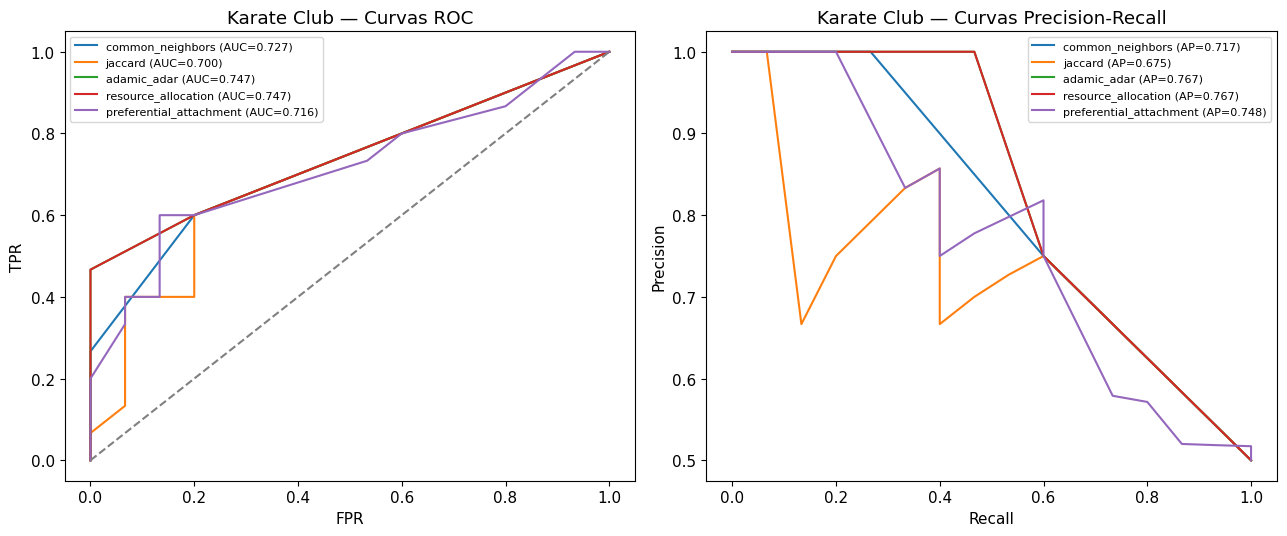

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for metodo in metodos:
    s = scores_karate[metodo]
    fpr_k, tpr_k, _ = roc_curve(y_karate, s)
    axes[0].plot(fpr_k, tpr_k, label=f'{metodo} (AUC={roc_auc_score(y_karate, s):.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Karate Club — Curvas ROC')
axes[0].legend(fontsize=8)

for metodo in metodos:
    s = scores_karate[metodo]
    prec_k, rec_k, _ = precision_recall_curve(y_karate, s)
    axes[1].plot(rec_k, prec_k, label=f'{metodo} (AP={average_precision_score(y_karate, s):.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Karate Club — Curvas Precision-Recall')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Avaliação em redes sintéticas

Vamos agora comparar o desempenho em três redes sintéticas com número de vértices e grau médio próximos aos do Karate Club, para investigar como a **topologia** afeta o desempenho dos métodos.

In [43]:
n_nos = G_karate.number_of_nodes()
grau_medio_alvo = 2 * G_karate.number_of_edges() / n_nos

G_er = nx.erdos_renyi_graph(n=n_nos, p=grau_medio_alvo / (n_nos - 1), seed=SEED)
G_ws = nx.watts_strogatz_graph(n=n_nos, k=max(2, int(round(grau_medio_alvo))), p=0.1, seed=SEED)
G_ba = nx.barabasi_albert_graph(n=n_nos, m=max(1, int(round(grau_medio_alvo / 2))), seed=SEED)

redes_sinteticas = {'Erdos-Renyi': G_er, 'Watts-Strogatz': G_ws, 'Barabasi-Albert': G_ba, 'Karate Club': G_karate}

for nome, Gr in redes_sinteticas.items():
    print(f'{nome:18s} n={Gr.number_of_nodes():3d}  m={Gr.number_of_edges():3d}  '
          f'grau_medio={2*Gr.number_of_edges()/Gr.number_of_nodes():.2f}  '
          f'conexo={nx.is_connected(Gr)}')

Erdos-Renyi        n= 34  m= 81  grau_medio=4.76  conexo=True
Watts-Strogatz     n= 34  m= 68  grau_medio=4.00  conexo=True
Barabasi-Albert    n= 34  m= 64  grau_medio=3.76  conexo=True
Karate Club        n= 34  m= 78  grau_medio=4.59  conexo=True


### Estatísticas estruturais adicionais

Além de grau médio e clustering, vamos calcular a **heterogeneidade de grau**, $\langle k^2 \rangle$, que mede o quanto os graus variam ao redor da média — redes com hubs muito pronunciados (como Barabási-Albert) têm $\langle k^2 \rangle$ bem mais alto.

In [44]:
resumo_redes = []
for nome, Gr in redes_sinteticas.items():
    graus_r = np.array([d for _, d in Gr.degree()])
    resumo_redes.append({
        'rede': nome,
        'n_nos': Gr.number_of_nodes(),
        'grau_medio': graus_r.mean(),
        'k2_medio': (graus_r ** 2).mean(),
        'clustering_medio': nx.average_clustering(Gr),
        'conexo': nx.is_connected(Gr),
    })

df_resumo_redes = pd.DataFrame(resumo_redes).round(3)
df_resumo_redes

,rede,n_nos,grau_medio,k2_medio,clustering_medio,conexo
0,Erdos-Renyi,34,4.765,25.529,0.121,True
1,Watts-Strogatz,34,4.000,16.529,0.384,True
2,Barabasi-Albert,34,3.765,27.059,0.367,True
3,Karate Club,34,4.588,35.647,0.571,True


### Desempenho dos métodos em cada rede

In [45]:
resultados_sinteticas = []

for nome, Gr in redes_sinteticas.items():
    if not nx.is_connected(Gr):
        print(f'{nome} não é conexa — pulando.')
        continue
    rng_rede = np.random.default_rng(SEED)
    Gr_train, pares_r, y_r = montar_experimento(Gr, frac_teste=0.20, rng=rng_rede)
    scores_r = calcular_scores_metodos(Gr_train, pares_r)

    for metodo in metodos:
        s = scores_r[metodo]
        resultados_sinteticas.append({
            'rede': nome,
            'metodo': metodo,
            'roc_auc': roc_auc_score(y_r, s),
            'average_precision': average_precision_score(y_r, s),
        })

df_resultados_sinteticas = pd.DataFrame(resultados_sinteticas).round(3)
tabela_pivot = df_resultados_sinteticas.pivot(index='metodo', columns='rede', values='roc_auc')
tabela_pivot

rede,Barabasi-Albert,Erdos-Renyi,Karate Club,Watts-Strogatz
metodo,,,,
adamic_adar,0.514,0.480,0.747,0.852
common_neighbors,0.472,0.473,0.727,0.820
jaccard,0.458,0.488,0.700,0.861
preferential_attachment,0.490,0.504,0.716,0.293
resource_allocation,0.514,0.477,0.747,0.852


### Estrutura da rede versus desempenho

Cada método carrega uma hipótese estrutural implícita sobre como a rede se formou:

- **Common Neighbors**: deve funcionar melhor quando há forte **fechamento triádico** (muitos triângulos).
- **Jaccard**: favorece pares cuja vizinhança **relativa** é semelhante, sendo útil quando os vértices têm graus muito diferentes entre si.
- **Adamic-Adar**: valoriza vizinhos comuns de **baixo grau** (mais "específicos", menos "hub").
- **Resource Allocation**: penaliza hubs comuns de forma ainda **mais forte** que Adamic-Adar.
- **Preferential Attachment**: pode funcionar melhor em redes com forte **heterogeneidade de grau** e crescimento por ligação preferencial, como no modelo de Barabási-Albert.

In [46]:
for nome in redes_sinteticas:
    if nome not in tabela_pivot.columns:
        continue
    melhor_metodo = tabela_pivot[nome].idxmax()
    print(f'{nome:18s} — clustering médio = {df_resumo_redes.set_index("rede").loc[nome, "clustering_medio"]:.3f}, '
          f'melhor método (ROC-AUC) = {melhor_metodo} ({tabela_pivot[nome].max():.3f})')

Erdos-Renyi        — clustering médio = 0.121, melhor método (ROC-AUC) = preferential_attachment (0.504)
Watts-Strogatz     — clustering médio = 0.384, melhor método (ROC-AUC) = jaccard (0.861)
Barabasi-Albert    — clustering médio = 0.367, melhor método (ROC-AUC) = adamic_adar (0.514)
Karate Club        — clustering médio = 0.571, melhor método (ROC-AUC) = adamic_adar (0.747)


O objetivo desta seção não é simplesmente apontar qual método "ganhou" em cada rede, mas entender por quê: métodos baseados em vizinhança comum tendem a se destacar em redes com clustering alto (Watts-Strogatz com baixo $p$, ou o próprio Karate Club), enquanto o Preferential Attachment tende a ser mais competitivo em redes com forte heterogeneidade de grau, como Barabási-Albert — mesmo sem qualquer noção de vizinhança compartilhada.

### Baseline aleatório

Um passo fundamental, e frequentemente negligenciado, em qualquer avaliação é comparar com um **baseline trivial**: um método que atribui escores completamente aleatórios.

In [47]:
rng_baseline = np.random.default_rng(SEED)
scores_aleatorios = rng_baseline.random(len(y_true))

auc_aleatorio = roc_auc_score(y_true, scores_aleatorios)
ap_aleatorio = average_precision_score(y_true, scores_aleatorios)
p10_aleatorio = precision_at_k(y_true, scores_aleatorios, 10)

print(f'Baseline aleatório — ROC-AUC:            {auc_aleatorio:.3f}')
print(f'Baseline aleatório — Average Precision:  {ap_aleatorio:.3f}')
print(f'Baseline aleatório — Precision@10:       {p10_aleatorio:.3f}')

Baseline aleatório — ROC-AUC:            0.583
Baseline aleatório — Average Precision:  0.114
Baseline aleatório — Precision@10:       0.100


Um método sofisticado que não supera claramente um baseline aleatório não apresenta evidência de utilidade real, por mais elaborada que seja sua formulação matemática. Todo novo método (especialmente os mais complexos, como embeddings ou GNNs) deveria ser comparado explicitamente com esse piso mínimo.

### Baseline baseado em grau

Um segundo baseline simples, mas mais informativo que o aleatório, usa apenas o grau dos vértices, sem qualquer noção de vizinhança compartilhada:

$$
s_{\text{grau}}(i,j) = k_i + k_j \qquad \text{ou} \qquad s_{\text{grau}}(i,j) = k_i \cdot k_j.
$$

(Note que a segunda opção é exatamente o Preferential Attachment já calculado, aqui usamos a soma, como uma variante ainda mais simples, para comparação.)

In [48]:
graus_train = dict(G_train.degree())
scores_soma_grau = np.array([graus_train[u] + graus_train[v] for u, v in df_avaliacao[['u', 'v']].values])

auc_soma_grau = roc_auc_score(y_true, scores_soma_grau)
ap_soma_grau = average_precision_score(y_true, scores_soma_grau)

print(f'Baseline soma de graus (k_i + k_j) — ROC-AUC:            {auc_soma_grau:.3f}')
print(f'Baseline soma de graus (k_i + k_j) — Average Precision:  {ap_soma_grau:.3f}')
print()
print(f'Comparação — Preferential Attachment (k_i * k_j):')
print(df_resumo.loc["preferential_attachment", ["roc_auc", "average_precision"]])

Baseline soma de graus (k_i + k_j) — ROC-AUC:            0.470
Baseline soma de graus (k_i + k_j) — Average Precision:  0.066

Comparação — Preferential Attachment (k_i * k_j):
roc_auc              0.517
average_precision    0.074
Name: preferential_attachment, dtype: float64


Comparar `k_i + k_j` com `k_i * k_j` (Preferential Attachment) e com os métodos baseados em vizinhança comum ajuda a responder uma pergunta importante: **quanto do desempenho observado pode ser explicado simplesmente pelo grau dos vértices**, sem qualquer informação sobre a topologia local mais fina? Se um baseline de grau já captura a maior parte do sinal, isso é uma informação valiosa sobre a rede em questão, e um alerta de que talvez o método mais sofisticado não esteja agregando tanto quanto parece.

### Problema temporal

Até aqui, tratamos a predição de links como **missing link prediction**: removemos arestas artificialmente de um grafo estático e tentamos recuperá-las. Existe, porém, um segundo cenário, conceitualmente diferente.

### Missing link prediction

Removemos artificialmente links de uma rede estática — como fizemos em todo este notebook. A rede "verdadeira" já contém essas conexões; apenas fingimos não observá-las.

### Future link prediction

Usamos a rede até um instante $t$,

$$
G_{\leq t},
$$

para prever os links que aparecerão **posteriormente**:

$$
E_{t+1}.
$$

### Por que a divisão aleatória pode ser errada aqui

Em redes temporais, escolher arestas de teste **aleatoriamente** (como fizemos até agora) pode ser metodologicamente incorreto: uma aresta formada em $t=3$ poderia, por exemplo, ser "prevista" usando informação de uma aresta formada em $t=8$, o que nunca seria possível na prática (não temos acesso ao futuro no momento da predição). A divisão deve respeitar a ordem temporal:

$$
t_{\text{treino}} < t_{\text{teste}}.
$$

Vamos ilustrar a ideia com uma sequência de grafos que crescem ao longo de "instantes" artificiais, sem implementar uma rede temporal complexa, apenas para tornar o conceito concreto.

In [49]:
# Sequência artificial de grafos que crescem no tempo
arestas_por_instante = {
    1: [(0, 1), (0, 2), (1, 2)],
    2: [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4)],
    3: [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (3, 5), (4, 5)],
}

G_t1 = nx.Graph(arestas_por_instante[1])
G_t2 = nx.Graph(arestas_por_instante[2])
G_t3 = nx.Graph(arestas_por_instante[3])

print(f'G_t1 (treino): {G_t1.number_of_edges()} arestas')
print(f'G_t2:          {G_t2.number_of_edges()} arestas')
print(f'G_t3 (teste — o "futuro"): {G_t3.number_of_edges()} arestas')

# Links que "aparecem" entre t=1 e t=3 (o alvo do future link prediction)
links_futuros = set(G_t3.edges()) - set(G_t1.edges())
print(f'Links formados após t=1: {links_futuros}')

G_t1 (treino): 3 arestas
G_t2:          5 arestas
G_t3 (teste — o "futuro"): 7 arestas
Links formados após t=1: {(2, 3), (4, 5), (3, 4), (3, 5)}


Nesse exemplo, calcularíamos os escores usando **apenas** `G_t1` (o que conhecíamos até aquele instante), e verificaríamos se os pares em `links_futuros` recebem escores altos, nunca usando `G_t2` ou `G_t3` no cálculo dos escores, pois isso seria informação do futuro.

### Um erro comum: negativos falsos

Uma questão sutil, mas importante, especialmente em **future link prediction**: um par atualmente classificado como negativo pode simplesmente representar uma conexão que **ainda não foi observada**, e não uma conexão que nunca ocorrerá.

Formalmente:

$$
(i, j) \notin E_t
$$

**não implica** que

$$
(i, j) \text{ nunca será uma aresta.}
$$

Isso torna a definição da classe negativa mais delicada em cenários temporais: alguns dos nossos "negativos" podem, na verdade, ser positivos que simplesmente ainda não se formaram no momento da observação. Esse fenômeno é análogo ao problema de rótulos ausentes (*missing labels*) em outras áreas de aprendizado de máquina: a ausência de um rótulo positivo não é o mesmo que a certeza de um rótulo negativo.

No cenário de **missing link prediction** (o que fizemos na maior parte deste notebook), esse problema é mais controlado, já que sabemos, pelo grafo original completo `G`, exatamente quais pares são de fato arestas, mas ele reaparece com força total ao lidar com redes reais e evolução temporal.

### Ranking versus classificação

Vale diferenciar claramente dois objetivos possíveis em predição de links.

#### Classificação

Queremos decidir, para cada par, um rótulo binário:

$$
y_{ij} \in \{0, 1\}.
$$

Isso exige escolher um limiar e produz decisões do tipo "sim, esse par vai se conectar" ou "não, não vai".

#### Ranking

Queremos apenas **ordenar** os pares:

$$
s(i_1, j_1) > s(i_2, j_2) > \cdots,
$$

dos mais prováveis para os menos prováveis — sem nunca precisar tomar uma decisão binária explícita.

#### Por que ranking costuma ser mais natural

Muitos problemas reais de predição de links são, na prática, problemas de **ranking**, não de classificação. Por exemplo:

> Um sistema de recomendação não precisa classificar todos os bilhões de pares possíveis como "conectar" ou "não conectar". Ele precisa apenas sugerir os 10 ou 20 melhores candidatos para cada usuário.

Essa observação é exatamente o que motiva o forte interesse em métricas como **Precision@k** e **Recall@k**: elas avaliam diretamente a qualidade do ranking na região que realmente importa na prática, sem exigir a escolha de um limiar global.

### Função geral de avaliação

Agora que todos os conceitos foram apresentados separadamente, podemos encapsular a lógica repetida em uma função auxiliar, para evitar reescrever o mesmo código nas próximas seções.

In [50]:
def avaliar_scores(y_true, scores, valores_k=(5, 10, 20)):
    '''Calcula ROC-AUC, Average Precision, Precision@k e Recall@k para um conjunto de escores.'''
    resultado_avaliacao = {
        'roc_auc': roc_auc_score(y_true, scores),
        'average_precision': average_precision_score(y_true, scores),
    }
    for k in valores_k:
        resultado_avaliacao[f'P@{k}'] = precision_at_k(y_true, scores, k)
        resultado_avaliacao[f'R@{k}'] = recall_at_k(y_true, scores, k)
    return resultado_avaliacao

# Testando a função com o que já calculamos manualmente
teste_funcao = avaliar_scores(y_true, df_avaliacao['common_neighbors'].values)
teste_funcao

{'roc_auc': 0.9225352112676056,
 'average_precision': 0.3125,
 'P@5': np.float64(0.2),
 'R@5': np.float64(0.2),
 'P@10': np.float64(0.1),
 'R@10': np.float64(0.2),
 'P@20': np.float64(0.25),
 'R@20': np.float64(1.0)}

A função `avaliar_scores` não introduz nenhuma metodologia nova, ela apenas reúne, em um único lugar, os cálculos que já fizemos. Mantivemos a implementação simples e direta, sem criar uma arquitetura excessivamente abstrata: o objetivo é reduzir repetição de código, não esconder a metodologia por trás de camadas de abstração.

### Experimento final

Vamos reunir tudo em um pequeno *benchmark*: quatro redes (Karate Club e as três redes sintéticas), seis "métodos" (os cinco índices estruturais mais o baseline aleatório), com múltiplas repetições para obter média e desvio padrão.

In [51]:
def avaliar_metodo_em_pares(nome_metodo, G_tr, pares, y, rng_local):
    if nome_metodo == 'baseline_aleatorio':
        return rng_local.random(len(pares))
    if nome_metodo == 'common_neighbors':
        return np.array([common_neighbors_score(G_tr, u, v) for u, v in pares])
    funcao_por_metodo = {
        'jaccard': nx.jaccard_coefficient,
        'adamic_adar': nx.adamic_adar_index,
        'resource_allocation': nx.resource_allocation_index,
        'preferential_attachment': nx.preferential_attachment,
    }
    funcao_nx = funcao_por_metodo[nome_metodo]
    mapa = {(u, v): sc for u, v, sc in funcao_nx(G_tr, pares)}
    return np.array([mapa[(u, v)] for u, v in pares])


metodos_benchmark = metodos + ['baseline_aleatorio']
redes_benchmark = {
    'Karate Club': G_karate,
    'Erdos-Renyi': G_er,
    'Watts-Strogatz': G_ws,
    'Barabasi-Albert': G_ba,
}
n_repeticoes_final = 15

registros_finais = []

for nome_rede, Gr in redes_benchmark.items():
    rng_bench = np.random.default_rng(SEED)
    for rep in range(n_repeticoes_final):
        Gr_train, pares_b, y_b = montar_experimento(Gr, frac_teste=0.20, rng=rng_bench)
        for nome_metodo in metodos_benchmark:
            s = avaliar_metodo_em_pares(nome_metodo, Gr_train, pares_b, y_b, rng_bench)
            aval = avaliar_scores(y_b, s, valores_k=(10,))
            registros_finais.append({
                'rede': nome_rede,
                'metodo': nome_metodo,
                'repeticao': rep,
                'roc_auc': aval['roc_auc'],
                'average_precision': aval['average_precision'],
                'P@10': aval['P@10'],
            })

df_registros_finais = pd.DataFrame(registros_finais)
print(f'Total de avaliações realizadas: {len(df_registros_finais)}')
df_registros_finais.head()

Total de avaliações realizadas: 360


,rede,metodo,repeticao,roc_auc,average_precision,P@10
0,Karate Club,common_neighbors,0,0.726667,0.716667,0.8
1,Karate Club,jaccard,0,0.700000,0.674517,0.7
2,Karate Club,adamic_adar,0,0.746667,0.766667,0.8
3,Karate Club,resource_allocation,0,0.746667,0.766667,0.8
4,Karate Club,preferential_attachment,0,0.715556,0.748202,0.8


In [52]:
tabela_final = (
    df_registros_finais
    .groupby(['rede', 'metodo'])[['roc_auc', 'average_precision', 'P@10']]
    .agg(['mean', 'std'])
    .round(3)
)

tabela_final

roc_auc        average_precision  \
                                           mean    std              mean   
rede            metodo                                                     
Barabasi-Albert adamic_adar               0.563  0.087             0.617   
                baseline_aleatorio        0.482  0.154             0.557   
                common_neighbors          0.535  0.090             0.545   
                jaccard                   0.488  0.095             0.496   
                preferential_attachment   0.682  0.151             0.754   
                resource_allocation       0.563  0.087             0.617   
Erdos-Renyi     adamic_adar               0.481  0.071             0.524   
                baseline_aleatorio        0.496  0.130             0.569   
                common_neighbors          0.490  0.075             0.516   
                jaccard                   0.496  0.079             0.525   
                preferential_attachment   0.425  0.061             0.477   
                resource_allocation       0.480  0.070             0.521   
Karate Club     adamic_adar               0.717  0.075             0.735   
                baseline_aleatorio        0.485  0.064             0.524   
                common_neighbors          0.693  0.077             0.682   
                jaccard                   0.635  0.093             0.608   
                preferential_attachment   0.692  0.071             0.726   
                resource_allocation       0.723  0.074             0.748   
Watts-Strogatz  adamic_adar               0.707  0.090             0.694   
                baseline_aleatorio        0.462  0.107             0.528   
                common_neighbors          0.695  0.086             0.664   
                jaccard                   0.725  0.091             0.736   
                preferential_attachment   0.239  0.069             0.406   
                resource_allocation       0.707  0.090             0.694   

                                                 P@10         
                                           std   mean    std  
rede            metodo                                        
Barabasi-Albert adamic_adar              0.066  0.460  0.130  
                baseline_aleatorio       0.102  0.460  0.155  
                common_neighbors         0.061  0.440  0.118  
                jaccard                  0.052  0.440  0.118  
                preferential_attachment  0.104  0.713  0.155  
                resource_allocation      0.066  0.460  0.130  
Erdos-Renyi     adamic_adar              0.048  0.440  0.130  
                baseline_aleatorio       0.103  0.500  0.146  
                common_neighbors         0.038  0.400  0.125  
                jaccard                  0.051  0.493  0.144  
                preferential_attachment  0.037  0.440  0.106  
                resource_allocation      0.044  0.440  0.130  
Karate Club     adamic_adar              0.071  0.747  0.099  
                baseline_aleatorio       0.053  0.520  0.115  
                common_neighbors         0.061  0.713  0.083  
                jaccard                  0.091  0.587  0.083  
                preferential_attachment  0.083  0.733  0.082  
                resource_allocation      0.070  0.747  0.099  
Watts-Strogatz  adamic_adar              0.097  0.680  0.142  
                baseline_aleatorio       0.076  0.480  0.126  
                common_neighbors         0.080  0.667  0.129  
                jaccard                  0.094  0.713  0.155  
                preferential_attachment  0.026  0.200  0.093  
                resource_allocation      0.097  0.680  0.142

#### Uma versão mais legível, em formato "média ± desvio"

In [53]:
def formatar_media_desvio(df, coluna):
    media = df[(coluna, 'mean')]
    desvio = df[(coluna, 'std')]
    return media.round(3).astype(str) + ' ± ' + desvio.round(3).astype(str)

tabela_legivel = pd.DataFrame({
    'ROC-AUC': formatar_media_desvio(tabela_final, 'roc_auc'),
    'Average Precision': formatar_media_desvio(tabela_final, 'average_precision'),
    'P@10': formatar_media_desvio(tabela_final, 'P@10'),
})

tabela_legivel

ROC-AUC Average Precision  \
rede            metodo                                                     
Barabasi-Albert adamic_adar              0.563 ± 0.087     0.617 ± 0.066   
                baseline_aleatorio       0.482 ± 0.154     0.557 ± 0.102   
                common_neighbors          0.535 ± 0.09     0.545 ± 0.061   
                jaccard                  0.488 ± 0.095     0.496 ± 0.052   
                preferential_attachment  0.682 ± 0.151     0.754 ± 0.104   
                resource_allocation      0.563 ± 0.087     0.617 ± 0.066   
Erdos-Renyi     adamic_adar              0.481 ± 0.071     0.524 ± 0.048   
                baseline_aleatorio        0.496 ± 0.13     0.569 ± 0.103   
                common_neighbors          0.49 ± 0.075     0.516 ± 0.038   
                jaccard                  0.496 ± 0.079     0.525 ± 0.051   
                preferential_attachment  0.425 ± 0.061     0.477 ± 0.037   
                resource_allocation        0.48 ± 0.07     0.521 ± 0.044   
Karate Club     adamic_adar              0.717 ± 0.075     0.735 ± 0.071   
                baseline_aleatorio       0.485 ± 0.064     0.524 ± 0.053   
                common_neighbors         0.693 ± 0.077     0.682 ± 0.061   
                jaccard                  0.635 ± 0.093     0.608 ± 0.091   
                preferential_attachment  0.692 ± 0.071     0.726 ± 0.083   
                resource_allocation      0.723 ± 0.074      0.748 ± 0.07   
Watts-Strogatz  adamic_adar               0.707 ± 0.09     0.694 ± 0.097   
                baseline_aleatorio       0.462 ± 0.107     0.528 ± 0.076   
                common_neighbors         0.695 ± 0.086      0.664 ± 0.08   
                jaccard                  0.725 ± 0.091     0.736 ± 0.094   
                preferential_attachment  0.239 ± 0.069     0.406 ± 0.026   
                resource_allocation       0.707 ± 0.09     0.694 ± 0.097   

                                                  P@10  
rede            metodo                                  
Barabasi-Albert adamic_adar                0.46 ± 0.13  
                baseline_aleatorio        0.46 ± 0.155  
                common_neighbors          0.44 ± 0.118  
                jaccard                   0.44 ± 0.118  
                preferential_attachment  0.713 ± 0.155  
                resource_allocation        0.46 ± 0.13  
Erdos-Renyi     adamic_adar                0.44 ± 0.13  
                baseline_aleatorio         0.5 ± 0.146  
                common_neighbors           0.4 ± 0.125  
                jaccard                  0.493 ± 0.144  
                preferential_attachment   0.44 ± 0.106  
                resource_allocation        0.44 ± 0.13  
Karate Club     adamic_adar              0.747 ± 0.099  
                baseline_aleatorio        0.52 ± 0.115  
                common_neighbors         0.713 ± 0.083  
                jaccard                  0.587 ± 0.083  
                preferential_attachment  0.733 ± 0.082  
                resource_allocation      0.747 ± 0.099  
Watts-Strogatz  adamic_adar               0.68 ± 0.142  
                baseline_aleatorio        0.48 ± 0.126  
                common_neighbors         0.667 ± 0.129  
                jaccard                  0.713 ± 0.155  
                preferential_attachment    0.2 ± 0.093  
                resource_allocation       0.68 ± 0.142

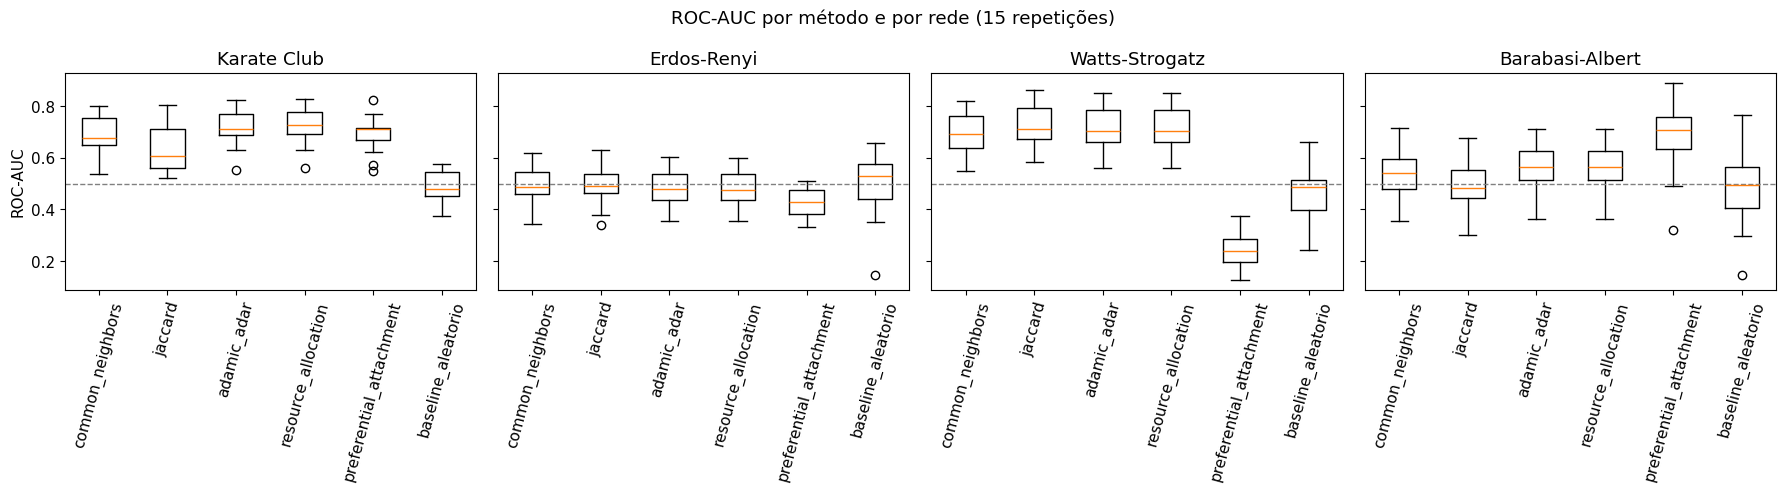

In [54]:
fig, axes = plt.subplots(1, len(redes_benchmark), figsize=(18, 5), sharey=True)

for ax, (nome_rede, _) in zip(axes, redes_benchmark.items()):
    subset = df_registros_finais[df_registros_finais['rede'] == nome_rede]
    dados_plot = [subset[subset['metodo'] == m]['roc_auc'] for m in metodos_benchmark]
    ax.boxplot(dados_plot, tick_labels=metodos_benchmark)
    ax.set_title(nome_rede)
    ax.tick_params(axis='x', rotation=75)
    ax.axhline(0.5, linestyle='--', color='gray', linewidth=1)

axes[0].set_ylabel('ROC-AUC')
plt.suptitle(f'ROC-AUC por método e por rede ({n_repeticoes_final} repetições)')
plt.tight_layout()
plt.show()

A linha cinza tracejada em $ROC\text{-}AUC = 0.5$ marca o desempenho esperado do baseline aleatório, qualquer método consistentemente abaixo dela estaria se saindo pior do que apostar aleatoriamente, o que seria um forte indício de erro metodológico (por exemplo, um sinal invertido). Observe como a posição relativa dos métodos muda de rede para rede, reforçando, com dados concretos, sobre a relação entre estrutura da rede e desempenho.

### Exercícios

1 - Na rede Karate Club, remova 10% das arestas e compare a ROC-AUC dos cinco métodos.

2 - Repita usando 20% e 30% das arestas como teste. Discuta como o desempenho muda.

3 - Compare a avaliação utilizando proporções positivos:negativos de 1:1, 1:5 e 1:10. Avalie ROC-AUC, Average Precision e Precision@10 (use `montar_experimento` e `avaliar_scores` como ponto de partida).

4 - Compare o desempenho de Common Neighbors em redes Watts-Strogatz com diferentes valores do parâmetro de reconexão `p` (por exemplo, 0.0, 0.1, 0.3, 0.5, 1.0). Relacione o desempenho ao coeficiente de clustering de cada rede gerada.